# Atelier 1 — EDA véhicules et CO2

Ce notebook vise à comprendre la structure du catalogue de véhicules nettoyé afin de préparer les étapes de modélisation supervisée et non supervisée.

L’objectif n’est pas de lancer immédiatement un modèle, mais de vérifier la qualité du dataset, la présence de valeurs manquantes, les distributions, les redondances et les risques de fuite ou de surreprésentation des familles.

## Étape 1 — Import, nettoyage léger des colonnes et chargement

Le fichier nettoyé contient des espaces parasites dans les noms de colonnes et dans certaines valeurs textuelles. Nous corrigeons cela dès le départ pour éviter de faire des erreurs de sélection de colonnes ou d’agrégation. Le cas d’usage métier est un catalogue de véhicules complet, et non des ventes, donc la structure est un peu différente d’un dataset de transactions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 20)

path = "../donnees_nettoyees/vehicules_analyse_conso_co2.csv"
df = pd.read_csv(path, sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.strip().str.lower()

for col in ["cnit", "lib_mrq_doss", "lib_mod_doss", "energ", "hybride", "typ_boite_nb_rapp"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df.head()

,cnit,lib_mrq_doss,lib_mod_doss,energ,hybride,typ_boite_nb_rapp,puiss_admin,puiss_max,masse_ordma_min,masse_ordma_max,conso_mixte,co2_mixte
0,M10ALFVP000G340,ALFA ROMEO,159,ES,non,M 6,12,147.0,1505,1505,7.8,182.0
1,M10ALFVP000H341,ALFA ROMEO,159,ES,non,M 6,12,147.0,1555,1555,8.0,186.0
2,M10ALFVP000E302,ALFA ROMEO,159,GO,non,M 6,7,100.0,1565,1565,5.1,134.0
3,M10ALFVP000F303,ALFA ROMEO,159,GO,non,M 6,7,100.0,1565,1565,5.1,134.0
4,M10ALFVP000J306,ALFA ROMEO,159,GO,non,M 6,7,100.0,1615,1615,5.2,137.0


## Étape 2 — Dimensions, types et valeurs manquantes

Avant de modéliser, il faut vérifier la taille du dataset, les types de colonnes et le nombre de valeurs nulles. Cela permet d’identifier les variables utiles, les éventuels points faibles et les limites des futurs modèles.

In [2]:
print("shape:", df.shape)
print("\nTypes de colonnes:")
print(df.dtypes.to_string())
print("\nValeurs manquantes:")
print(df.isna().sum().sort_values(ascending=False).head(20).to_string())
print("\nAperçu:")
display(df.head(3))

shape: (20824, 12)

Types de colonnes:
cnit                     str
lib_mrq_doss             str
lib_mod_doss             str
energ                    str
hybride                  str
typ_boite_nb_rapp        str
puiss_admin            int64
puiss_max            float64
masse_ordma_min        int64
masse_ordma_max        int64
conso_mixte          float64
co2_mixte            float64

Valeurs manquantes:
cnit                 0
lib_mrq_doss         0
lib_mod_doss         0
energ                0
hybride              0
typ_boite_nb_rapp    0
puiss_admin          0
puiss_max            0
masse_ordma_min      0
masse_ordma_max      0
conso_mixte          0
co2_mixte            0

Aperçu:


,cnit,lib_mrq_doss,lib_mod_doss,energ,hybride,typ_boite_nb_rapp,puiss_admin,puiss_max,masse_ordma_min,masse_ordma_max,conso_mixte,co2_mixte
0,M10ALFVP000G340,ALFA ROMEO,159,ES,non,M 6,12,147.0,1505,1505,7.8,182.0
1,M10ALFVP000H341,ALFA ROMEO,159,ES,non,M 6,12,147.0,1555,1555,8.0,186.0
2,M10ALFVP000E302,ALFA ROMEO,159,GO,non,M 6,7,100.0,1565,1565,5.1,134.0


## Étape 3 — Statistiques descriptives et premières distributions

Les variables techniques comme la puissance, la masse et l’émission de CO2 sont essentielles ici. Il faut aussi repérer les distributions aberrantes ou fortement asymétriques, car elles influencent le choix des modèles et le besoin de transformation.

,count,mean,std,min,25%,50%,75%,max
puiss_admin,20824.0,12.42,9.75,2.0,8.0,9.0,12.0,80.0
puiss_max,20824.0,146.09,80.11,28.0,100.0,120.0,150.0,585.0
masse_ordma_min,20824.0,1810.74,371.72,875.0,1505.0,1760.0,2050.0,2765.0
masse_ordma_max,20824.0,1846.76,429.07,875.0,1508.0,1760.0,2050.0,3084.0
conso_mixte,20824.0,6.22,1.93,0.6,4.8,5.8,7.1,17.2
co2_mixte,20824.0,154.58,44.25,13.0,122.0,147.0,180.0,398.0


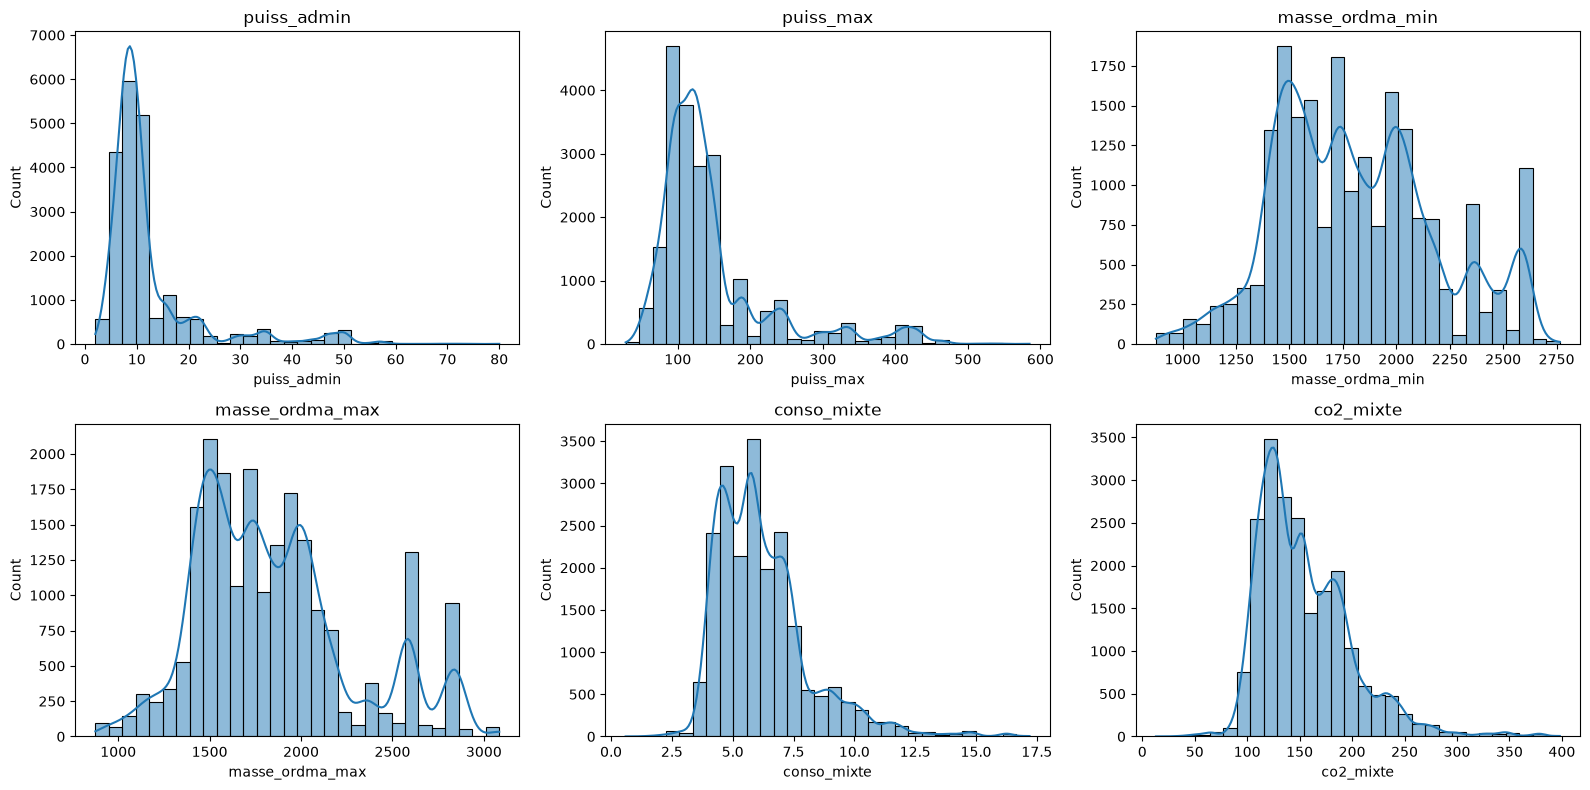

In [3]:
numeric_cols = [
    "puiss_admin", "puiss_max", "masse_ordma_min", "masse_ordma_max", "conso_mixte", "co2_mixte"
]
summary = df[numeric_cols].describe().T
display(summary.round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Étape 4 — Boxplots et repérage des valeurs extrêmes

Les boxplots aident à distinguer la dispersion normale d’un ensemble de véhicules d’un sous-ensemble plus extrême. C’est utile pour mesurer le risque de variable aberrante ou d’un sous-groupe très spécifique avant la modélisation.

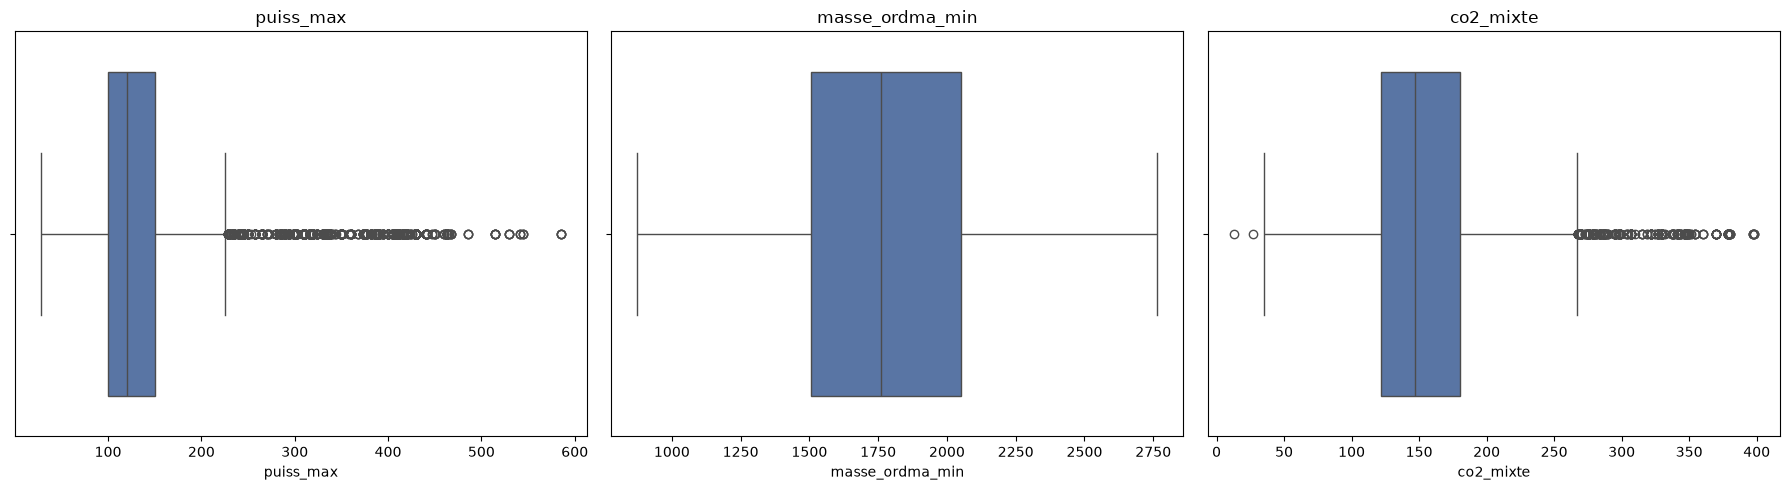

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["puiss_max", "masse_ordma_min", "co2_mixte"]):
    sns.boxplot(data=df, x=col, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Étape 5 — Corrélations et risques métier

Le CO2 est fortement lié à la consommation, à la puissance et à la masse. La voiture ne doit pas être vue comme un simple point isolé : les variantes proches d’une même famille partagent des propriétés quasiment identiques, ce qui peut fausser les performances si le split train/test n’est pas effectué par famille.

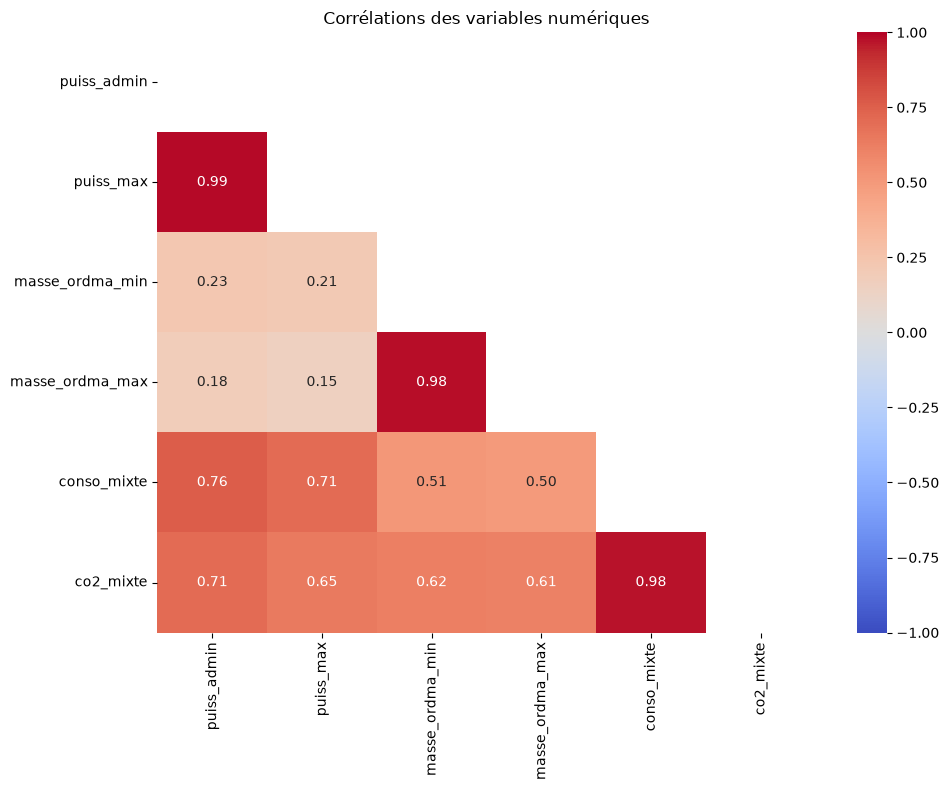

Nombre de familles distinctes : 444
Top 10 familles les plus fréquentes :
MERCEDES BENZ | CLASSE E      3044
MERCEDES BENZ | CLASSE C      2907
MERCEDES BENZ | SPRINTER      2697
MERCEDES BENZ | VITO          1026
MERCEDES BENZ | CLASSE S       980
MERCEDES BENZ | CLASSE V       846
MERCEDES BENZ | CLASSE CLA     503
MERCEDES BENZ | CLASSE B       442
MERCEDES BENZ | CLASSE A       354
MERCEDES BENZ | CLASSE CLS     346

Nombre de variantes quasi dupliquées (même famille) : 3044
Données en double sur cnit : 61


In [5]:
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", mask=mask, vmin=-1, vmax=1)
plt.title("Corrélations des variables numériques")
plt.tight_layout()
plt.show()

famille = df["lib_mrq_doss"].fillna("").astype(str) + " | " + df["lib_mod_doss"].fillna("").astype(str)
famille_counts = famille.value_counts()
print("Nombre de familles distinctes :", famille.nunique())
print("Top 10 familles les plus fréquentes :")
print(famille_counts.head(10).to_string())
print("\nNombre de variantes quasi dupliquées (même famille) :", famille_counts.max())
print("Données en double sur cnit :", df["cnit"].duplicated().sum())

## Synthèse finale

Cette exploration doit être interprétée à la lumière des résultats obtenus. Les variables utiles sont surtout les caractéristiques techniques, tandis que `conso_mixte` et les identifiants ne sont ni adaptés à la prédiction de `co2_mixte` ni sûrs pour un train/test aléatoire. Le principal risque métier est la présence de familles très représentées et de variantes quasi identiques, ce qui impose un split par famille pour évaluer correctement la généralisation.